# 分類 (classification)
### MNIST data: hand-written characters of digits
### 手書き数字認識
NIST: National Institute of Standards and Technology, US
アメリカ国立標準技術研究所

MNIST: Modified National Institute of Standards and Technology database

## Deep neural network, or deep learning
### Frameworks for neural networks
### ディープニューラルネットワーク用フレームワーク
- TensorFlow (Google, California) + Keras
- Torch, PyTorch (Facebook, California)
- Chainer (Preferred Networks, Tokyo)
- Caffe (Yangqing Jia, UCBerkeley)
- Theano (Bengio, et al., Canada)

等があるが，今回はディープラーニングは使わない．

## Scikit-Learn

Python の機械学習の総合ライブラリで，ディープラーニング以外は全て実装されている．今回は，これを使う．
（Deep ではない機械学習を shallow な機械学習と呼ぶ研究者もいる）

```python
from sklearn import datasets, metrics
#from keras.datasets import mnist
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt
 # データはインターネットから取ってきて，
 # 訓練(学習)用の入力(x)・出力(y)，テスト用の入力(x)・出力(y) に代入
#(x_train, y_train), (x_test, y_test) = mnist.load_data()
x, y = fetch_openml('mnist_784', version=1, return_X_y=True)
```

In [2]:
from sklearn import datasets, metrics
# from keras.datasets import mnist
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt
 # データはインターネットから取ってきて，
 # 訓練(学習)用の入力(x)・出力(y)，テスト用の入力(x)・出力(y) に代入
# (x_train, y_train), (x_test, y_test) = mnist.load_data()
x, y = fetch_openml('mnist_784', version=1, return_X_y=True)

In [3]:
x

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
y

,class
0,5
1,0
2,4
3,1
4,9
...,...
69995,2
69996,3
69997,4
69998,5


Scikit Learn で読み込む MNIST 手書き数字データは，784次元の画像データ（28×28ピクセル）が，70000個入っている．

本来 MNIST データは，
*   最初の60000個が訓練データ
*   残りの10000個がテストデータ

検証データは当時はなかった．

またこの形は，Pandas パッケージのデータフレーム（統計ソフト R で用いられるデータ形式で，表形式データ）なので，Scikit-Learn は NumPy の配列 (n-dimenstional array = ndarray) を使うので，変換する．

データフレームの「values」属性（プロパティ）を使うことで取り出せる．
（教科書 p.324 ）

（教科書では，データ行列を大文字 X で表すが，ここでは小文字 x で進める）

In [5]:
x = x.values         # オブジェクト x に，x.values とすると，values 属性(プロパティ)を取り出せる (numpy の ndarray 配列形式になる)
y = y.astype(int).values    # ラベルデータとして整数(int)型にしたいので，astype(int)で変換（しないと 1.00 のような浮動小数点型 (float) になる

1個目のデータは，
```python
x[0]
```
として取り出せる．

In [6]:
type(y)

numpy.ndarray

### 【補足】
### 各クラスのデータ数（support = サポート = 台数 = 集合の要素数）を見る．python の range 関数や内包記法についても．
numpy の count_nonzero 関数を用いて ndarray 配列の要素数を見ることができる．
```python
np.count_nonzero(y) -> y の要素数 (0でないもの)
np.count_nonzero(y == 2) -> y の値が2 であるものの要素数（条件式を書ける）
```


In [7]:
np.count_nonzero(y == 0)

6903

In [8]:
###
print("y=1 の要素数")
print(np.count_nonzero(y == 1))
###
print("y=0 から 9 までの要素数")
for i in range(10):
  print( np.count_nonzero(y == i) )
###
print("y=0 から 9 までの要素数．内包記法で．より効率的")
print([np.count_nonzero(y == i) for i in range(10)])

y=1 の要素数
7877
y=0 から 9 までの要素数
6903
7877
6990
7141
6824
6313
6876
7293
6825
6958
y=0 から 9 までの要素数．内包記法で．より効率的
[6903, 7877, 6990, 7141, 6824, 6313, 6876, 7293, 6825, 6958]


In [9]:
# 数字の列を全て書かずに生成させる．range(どこから，どこまで(一つ手前)，何個飛ばし)，省略すると range (0からどこまで(1個手前)，1つずつ)
print( list(range(10)) )
print( list(range(4,20,3)) )
print( list(range(20,4,-3)) )

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[4, 7, 10, 13, 16, 19]
[20, 17, 14, 11, 8, 5]


### データを見る (See the data)
matplotlib (plt) の imshow 関数で2次元配列を表示することができる  
cmap はカラーマップ (色付け)，指定なしの場合は黄色と青  
ここでｈ，gray(グレー) の r (白黒反転 reverse)
```python
plt.imshow(x[0], cmap='gray_r')
```
で1個目のデータを見てみる．

（imshow は，matplotlib.plot の2次元配列を画像 (image) として表示する機能）

ただしこのままでは，元の x[0] は1次元配列 (784次元) で表示できないので，numpy.ndarray である x[0] の reshape メソッド (総要素数を変えずに，1次元 784 を 2次元 28x28 に変換する)． (教科書 p.325)

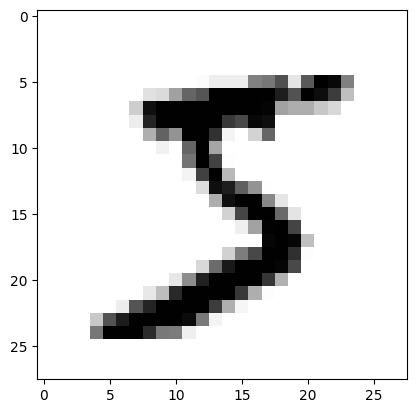

In [10]:
plt.imshow(x[0].reshape(28, 28),  cmap='gray_r')

## **課題1：150個目のデータを見る**

KUTLMS（課題1 第2回(6/12))から答える
https://lms.kochi-tech.ac.jp/mod/quiz/view.php?id=236237

### 教師出力（正解）を見る
Ground Truth (正解) と呼ぶ
```python
y[0]
```

In [11]:
y[0]

np.int64(5)

## データをまず訓練 (train) とテスト (test) に分ける
```python
x_train, x_test = x[0:60000], X[60000:70000]
y_train, y_test = y[0:60000], y[60000:70000]
```
[a:b] と書くのは，配列 ndarray の a 個目(「0」が1個目）から，b - 1 個目までを取り出す操作．最初と最後は，省略していいので，
```python
x_train, x_test = x[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]
```
と書いても一緒．

ハイパーパラメータチューニングやモデル比較をする際は，更に，訓練データから検証データ (validation (val) ) を分けておく必要があるが，今日は valid は使わない（教科書 p.326）．

In [12]:
x_train, x_test = x[0:60000], x[60000:70000]
y_train, y_test = y[0:60000], y[60000:70000]

## 最初の5個のデータを for 文で表示
### See 5 data from the first
subplot を使うことで1つの図内に横に5つ並べて表示する  
subplot 関数の引数（縦の行数，横の列数，左上から数えて何番目の位置に書くか指定(1から数える)）  
下記の例は，1行5列に5個表示する．
```python
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.title(i)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
```

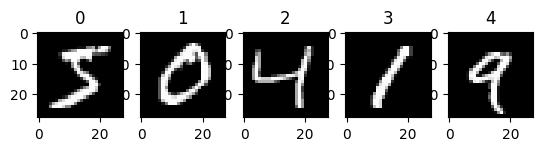

In [13]:
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.title(i)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')

# 課題2 : 15個のデータを3行5列で表示しなさい．

ヒント，range(5) と subplot の行を書き換えればできます．
subplot の行を，KUTLMS 課題2に書いてください．

In [14]:
15個のデータを3行5列で表示しなさい

SyntaxError: invalid syntax (1452017578.py, line 1)

### 計算時間短縮のため，データを60000個のうち最初の1000個だけを使う
Number of data is restricted to 1000 because of the computation cost
```python
data_size = 1000
x_train1 = x_train[0:data_size]
y_train1 = y_train[0:data_size]
x_test1 = x_test[0:data_size]
y_test1 = y_test[0:data_size]
```

In [15]:
data_size = 1000
x_train1 = x_train[0:data_size]
y_train1 = y_train[0:data_size]
x_test1 = x_test[0:data_size]
y_test1 = y_test[0:data_size]

# ここから，教科書3章に出てくる様々な分類器を使って，MNIST 分類（文字認識（パターン認識），予測）をする．

# 1. ロジスティック回帰 (Logistic regression)
### ライブラリを読み込む
load library

教科書 p.69 (3.3.4節)

```python
from sklearn.linear_model import LogisticRegression
```

In [16]:
from sklearn.linear_model import LogisticRegression

### 分類器を定義する
Define classifier
ここでは，ロジスティック回帰モデル（線形回帰モデルを分類に使うモデル）を clf_lr （分類器_ロジ回帰の略）として定義
```python
clf_lf = LogisticRegression()
```

In [17]:
clf_lf = LogisticRegression()

In [18]:
clf_lf

LogisticRegression()

### 学習を行う (訓練，fit とも言う)．
訓練データを使う
### Train (fit) the model using training data
```python
clf_lf.fit(x_train1, y_train1)
```

In [19]:
clf_lf.fit(x_train1, y_train1)

LogisticRegression()

### テストデータで性能を評価する
### Evaluate the model accuracy using test data
```python
clf_lf.score(x_test1, y_test1)
```

In [20]:
clf_lf.score(x_test1, y_test1)

0.816

In [21]:
clf_lf.score(x_train1, y_train1)

1.0

### まだ見たことのないテストデータを予測（predict, ここでは認識）してみる
array (配列) 形式で出力される．複数の入力をまとめて与えたら複数出力される．  
ここでは，1つの入力のみなので，1つの要素の配列が出力．  
配列の要素 [0] を最後に記述すれば，値を取り出せる．
### Predict unseen value using test input
```python
clf_lf.predict(x_test1[[0]])
```

In [22]:
clf_lf.predict(x_test1[[0]])

array([7])

In [23]:
clf_lf.predict_proba(x_test1[[0]]).reshape(10,) # 各クラスの確率が分かる

array([4.97846191e-23, 3.39127647e-45, 2.85429962e-19, 1.53518429e-15,
       2.73864155e-31, 2.35088902e-25, 4.08165351e-40, 1.00000000e+00,
       3.68209666e-22, 1.18875324e-18])

<BarContainer object of 10 artists>

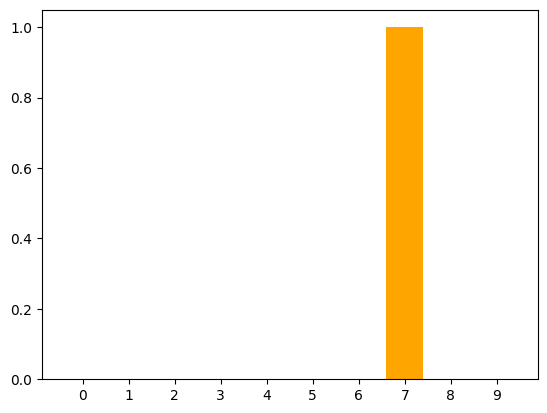

In [24]:
#各クラスの確率をグラフで見てみる
classes = list(map(str, range(10)))
#classes = ['0','1','2','3','4','5','6','7','8','9']
probabilities = clf_lf.predict_proba(x_test1[[0]]).reshape(10,)
plt.bar(classes, probabilities, color=['orange'])

<BarContainer object of 3 artists>

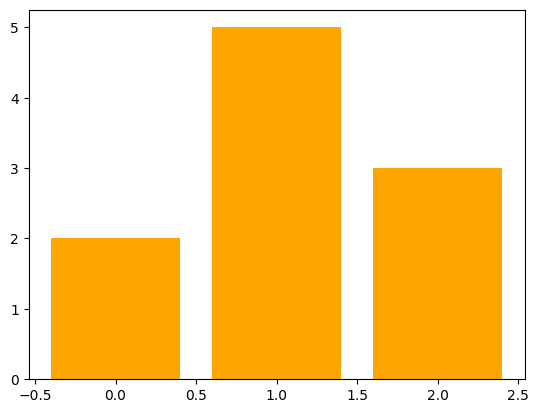

In [25]:
plt.bar([0,1,2],[2,5,3],color=['orange'])

### x_test1 の1000個のテストデータを全て predict し，predicted に代入
### 正解データ y_test1 を expected (期待される出力) に代入
### predict value y' and true value (expected value) y
```python
predicted = clf_lf.predict(x_test1)
expected = y_test1
```

In [26]:
predicted = clf_lf.predict(x_test1)
expected = y_test1

### 正解 expected と 予測結果 predicted を使って精度を評価
答え合わせをする
### See the detail evaluation
```
print(metrics.classification_report(expected, predicted))
```

In [27]:
print(metrics.classification_report(expected, predicted))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95        85
           1       0.98      0.98      0.98       126
           2       0.82      0.81      0.81       116
           3       0.77      0.72      0.74       107
           4       0.86      0.85      0.85       110
           5       0.69      0.71      0.70        87
           6       0.87      0.86      0.87        87
           7       0.70      0.76      0.73        99
           8       0.76      0.72      0.74        89
           9       0.73      0.76      0.74        94

    accuracy                           0.82      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.82      0.82      0.82      1000



| Index | 指標 | 意味 |
| ---- | ---- | ---- |
| Precision | **適合率** |  0 と予測した物のうち正解だった物|
| Recall | **再現率** | 本来 0 である物のうち，いくつ 0 と予測できたか|
| F1-score | **F1スコア** | 適合率と再現率の調和平均，F値，Fスコアとも|
| Support | **台集合，サポート** | 正解データ数|
| Accuracy | **正答率，正解率** | 予測全体のうちの正解予測数|



# **混同行列を表示し検討する**
### See the confusion matrix for detail
```
print(metrics.confusion_matrix(expected, predicted))
```

In [28]:
print(metrics.confusion_matrix(expected, predicted))

[[ 81   0   0   1   1   0   0   1   0   1]
 [  0 124   1   1   0   0   0   0   0   0]
 [  1   1  94   4   0   0   3   5   6   2]
 [  0   0   3  77   1  19   1   3   3   0]
 [  0   1   0   2  93   1   2   0   0  11]
 [  1   1   2   1   5  62   2   3   8   2]
 [  2   0   2   0   2   4  75   0   2   0]
 [  0   0  10   7   2   1   0  75   0   4]
 [  1   0   3   4   3   1   3   4  64   6]
 [  0   0   0   3   1   2   0  16   1  71]]


## 混同行列の見方
縦の各行は，正解クラス「0」～「9」  
横の各列は，予測クラス「0」～「9」  

行列の各要素 ij (i行j列) の値は，正解 i のものを j と予測した個数．

### 混同行列を色付きで表示
### See the confusion matrix by graphical illustration

```python
import seaborn as sns
confmat = metrics.confusion_matrix(expected, predicted)
plt.figure(figsize=(16,16))
sns.heatmap(confmat, annot=True, fmt=".3f", square = True, cmap = 'Blues_r')
plt.ylabel('Expected Class')
plt.xlabel('Predicted label')
```

Text(0.5, 266.7222222222221, 'Predicted label')

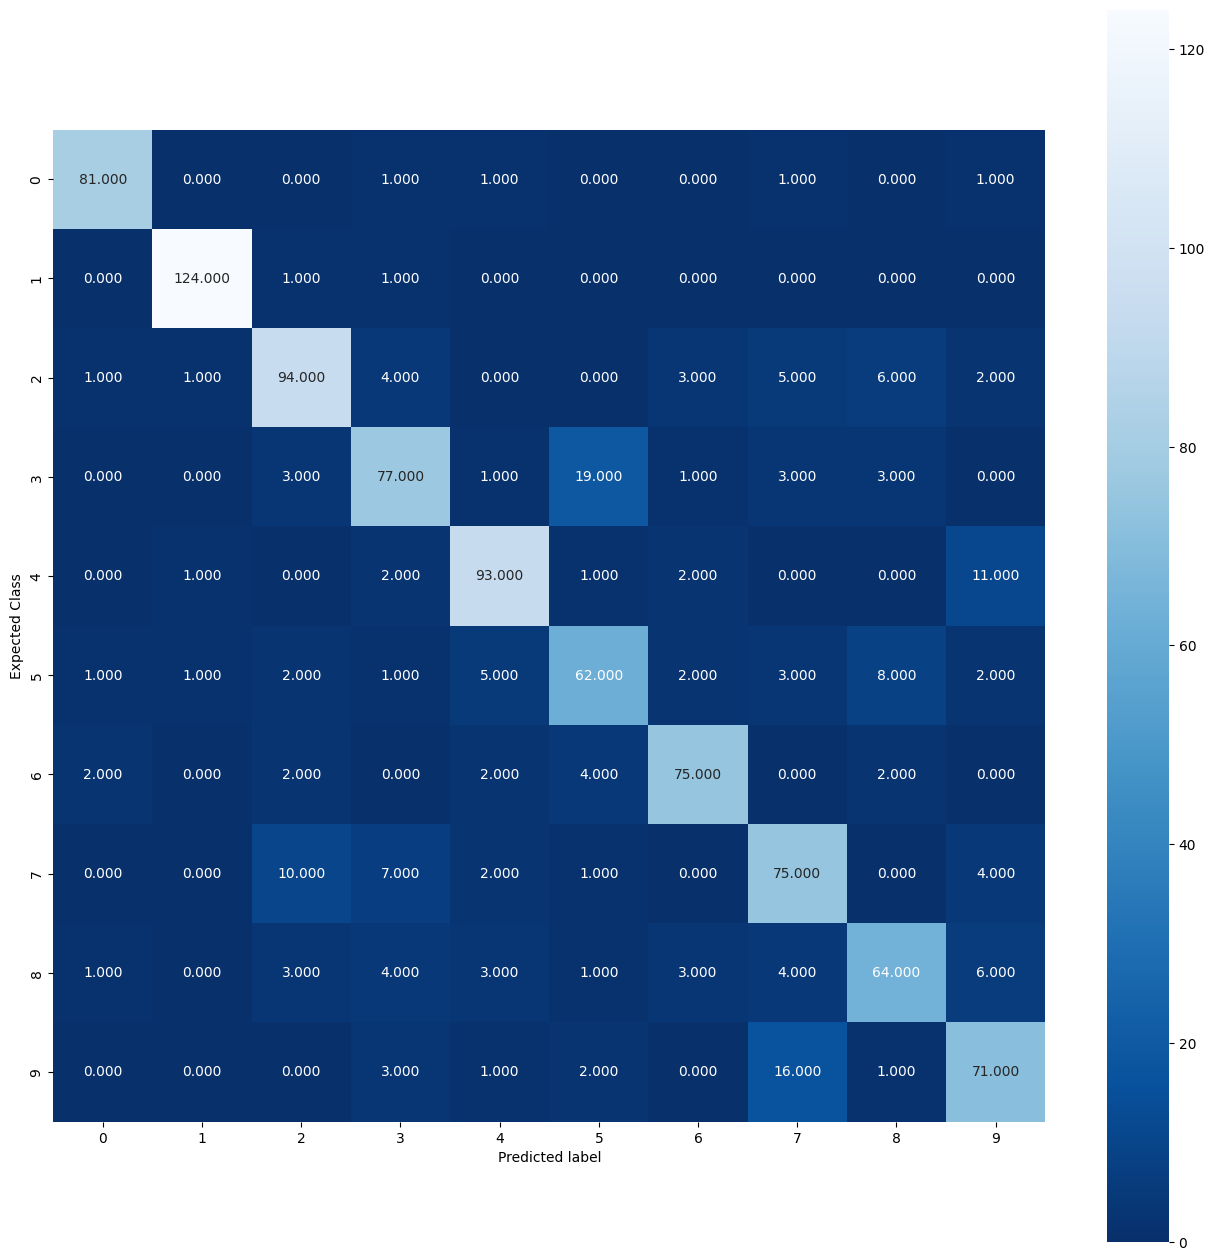

In [29]:
import seaborn as sns
confmat = metrics.confusion_matrix(expected, predicted)
plt.figure(figsize=(16,16))
sns.heatmap(confmat, annot=True, fmt=".3f", square = True, cmap = 'Blues_r')
plt.ylabel('Expected Class')
plt.xlabel('Predicted label')

## ロジスティック回帰の係数を見る
### See the coefficients
```
clf_lf.coef_
```

In [30]:
clf_lf.coef_

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

## ロジスティック回帰の切片を見る
###See the intercept of the line
```
clf_lf.intercept_
```

In [31]:
clf_lf.intercept_

array([-3.28328360e-05,  2.76071976e-05,  1.79846783e-07, -8.28534450e-06,
        1.16126667e-06,  4.16905183e-05,  1.34094920e-05,  5.24847430e-05,
       -9.00981095e-05, -5.31677445e-06])

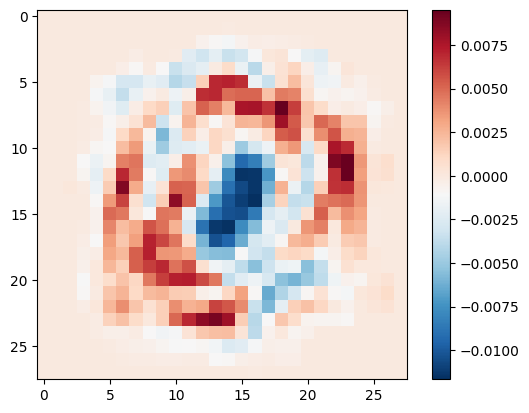

In [32]:
plt.imshow(clf_lf.coef_[0].reshape(28, 28), cmap="RdBu_r")
plt.colorbar()

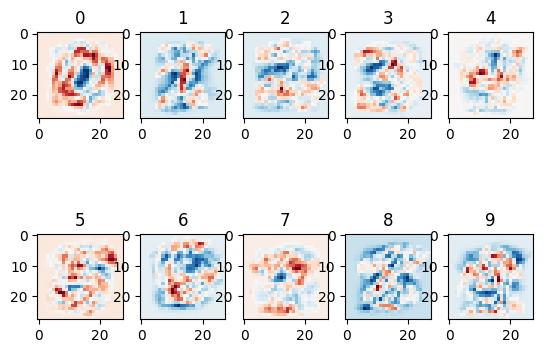

In [33]:
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.title(i)
    plt.imshow(clf_lf.coef_[i].reshape(28, 28), cmap="RdBu_r")
    #plt.colorbar()

<BarContainer object of 10 artists>

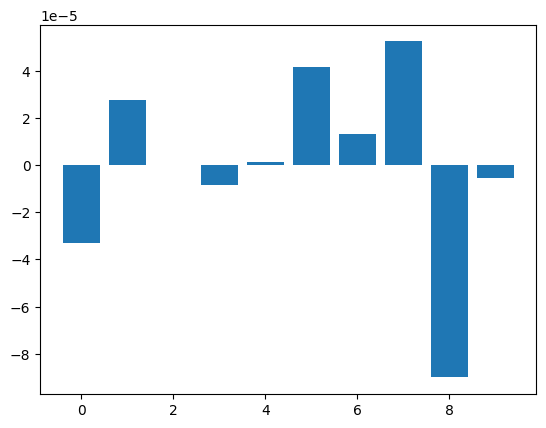

In [34]:
plt.bar(range(10), clf_lf.intercept_)

## 誤認識したデータを確認する
### See incorrectly classified data
何番目のデータについて，本来正解の値と，予測した値
```python
i = 0
mis_idx = []
for exp, pred in zip(expected, predicted):
    if exp != pred:
        print(i, exp, pred)
        mis_idx.append(i)
    i = i + 1
```

In [35]:
i = 0
mis_idx = []
for exp, pred in zip(expected, predicted):
    if exp != pred:
        print(i, exp, pred)
        mis_idx.append(i)
    i = i + 1

1 2 6
8 5 2
15 5 4
22 6 4
44 3 5
53 5 4
63 3 2
64 7 2
66 6 2
73 9 7
80 7 9
87 3 5
97 7 3
99 9 7
122 7 3
124 7 4
126 0 3
133 7 2
142 3 7
149 2 9
159 4 9
172 2 3
193 9 3
198 4 9
211 5 0
212 9 3
217 6 5
230 3 5
233 8 7
235 9 7
241 9 5
242 8 9
243 7 3
245 3 5
247 4 6
255 7 3
261 5 1
264 9 3
268 8 4
274 9 7
275 4 9
282 7 2
284 9 7
289 5 6
290 8 4
300 4 6
301 7 2
307 7 9
313 3 5
317 5 8
318 2 3
319 5 4
320 9 7
321 2 7
324 0 7
338 8 0
344 8 6
349 3 7
352 5 3
358 7 9
362 2 7
367 5 4
370 7 3
376 4 9
386 6 5
389 9 8
397 5 8
403 8 9
429 8 2
433 5 8
435 8 7
444 2 8
445 6 0
447 4 9
448 9 5
449 3 5
450 3 5
453 3 2
456 2 8
457 6 5
465 8 7
468 7 2
469 5 8
478 5 8
479 9 7
483 5 7
488 9 7
495 8 2
507 3 5
508 6 8
509 5 8
511 4 1
514 6 4
515 3 8
524 3 5
527 8 3
531 3 6
532 4 9
536 2 1
543 8 3
548 3 5
551 7 3
552 0 9
553 8 6
560 9 7
565 4 9
569 3 4
578 3 8
583 2 7
588 5 9
591 8 3
605 7 2
610 4 3
612 2 6
613 2 8
627 9 7
629 2 6
638 5 7
654 5 7
658 7 4
659 2 9
673 9 4
678 9 7
683 3 5
684 7 3
689 7 9
691 8 4


## 全部でいくつ間違えているかを表示
### Number of incorrectly classified data
```python
len(mis_idx)
```

In [36]:
len(mis_idx)

184

## 間違えたデータの最初の50個を表示
### See the first 50 misclassified data
```python
plt.figure(figsize=(16,16))
for i, ng in enumerate(mis_idx[0:50]):
    plt.subplot(5, 10, i + 1)
    plt.imshow(x_test[ng], cmap='gray_r')
    plt.title('Pred: {}, Ans: {}'.format(predicted[ng], expected[ng]), fontsize = 8)
```

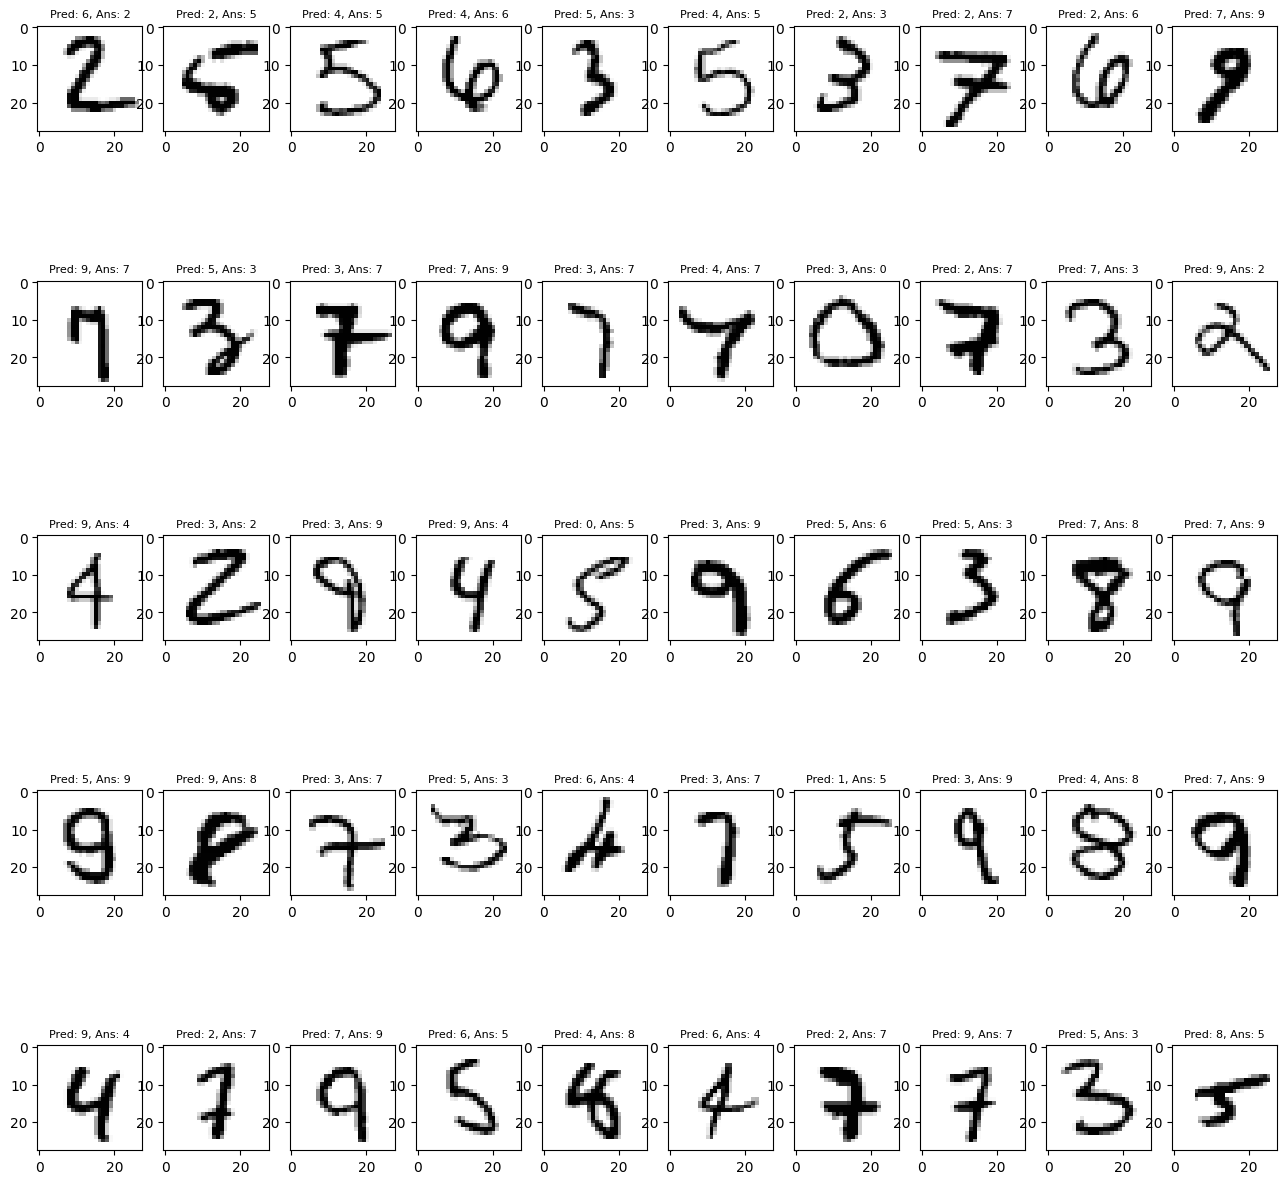

In [37]:
plt.figure(figsize=(16,16))
for i, ng in enumerate(mis_idx[0:50]):
    plt.subplot(5, 10, i + 1)
    plt.imshow(x_test[ng].reshape(28, 28), cmap='gray_r')
    plt.title('Pred: {}, Ans: {}'.format(predicted[ng], expected[ng]), fontsize = 8)

# 2. SVM : サポートベクトルマシン
support vector machine

非線形のモデルで，汎化性能が高い．

3.4.2 節 (p.77) の SVC （サポートベクトル分類器）を使う．

### Load library
```python
from sklearn.svm import SVC
```

In [38]:
from sklearn.svm import SVC

## 線形カーネル（＝カーネルトリックを使わない）モデルを作る
```python
clf_svml = SVC(kernel='linear')
```

In [39]:
clf_svml = SVC(kernel='linear')

### 訓練（Train = fit) する
```python
clf_svml.fit(x_train1, y_train1)
```

In [40]:
clf_svml.fit(x_train1, y_train1)

SVC(kernel='linear')

```python
predicted_svml = clf_svml.predict(x_test1)
expected_svml = y_test1
```

In [41]:
predicted_svml = clf_svml.predict(x_test1)
expected_svml = y_test1

```python
print(metrics.classification_report(expected_svml, predicted_svml))
```

In [42]:
print(metrics.classification_report(expected_svml, predicted_svml))

              precision    recall  f1-score   support

           0       0.94      0.93      0.93        85
           1       0.96      0.99      0.98       126
           2       0.88      0.90      0.89       116
           3       0.87      0.77      0.82       107
           4       0.86      0.85      0.86       110
           5       0.69      0.83      0.75        87
           6       0.89      0.89      0.89        87
           7       0.80      0.83      0.82        99
           8       0.87      0.70      0.78        89
           9       0.76      0.81      0.78        94

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.86      0.85      0.85      1000



In [43]:
print(metrics.confusion_matrix(expected_svml, predicted_svml))



[[ 79   0   0   0   1   3   2   0   0   0]
 [  0 125   0   0   0   0   0   1   0   0]
 [  1   0 104   0   1   0   3   5   2   0]
 [  0   2   2  82   0  16   1   0   4   0]
 [  0   1   0   0  94   1   2   0   0  12]
 [  0   1   1   1   2  72   1   3   2   4]
 [  2   0   3   0   2   3  77   0   0   0]
 [  0   0   6   2   4   1   0  82   0   4]
 [  2   1   2   6   1   7   1   3  62   4]
 [  0   0   0   3   4   2   0   8   1  76]]


## 3. カーネルを変えたサポートベクトルマシン

RBF カーネル（3.5.2節 p.80-81，ガウスカーネルとも呼ぶ）や，多項式カーネル（2次関数，3次関数，etc. scikit-learn のマニュアル https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC 等も参考に）を使ったモデルを使う．

In [44]:
clf_svmr = SVC(kernel='sigmoid')
clf_svmr.fit(x_train1, y_train1)
predicted_svmr = clf_svmr.predict(x_test1)
expected_svmr = y_test1
print(metrics.classification_report(expected_svmr, predicted_svmr))


              precision    recall  f1-score   support

           0       0.89      0.91      0.90        85
           1       0.94      0.98      0.96       126
           2       0.86      0.77      0.81       116
           3       0.82      0.62      0.71       107
           4       0.80      0.83      0.81       110
           5       0.57      0.74      0.64        87
           6       0.89      0.83      0.86        87
           7       0.78      0.84      0.81        99
           8       0.78      0.71      0.74        89
           9       0.73      0.80      0.76        94

    accuracy                           0.80      1000
   macro avg       0.81      0.80      0.80      1000
weighted avg       0.81      0.80      0.80      1000



# 4. パーセプトロン，Perceptron
- 最も簡素なニューラルネットワーク (Most simple neural network)
- マカロックピッツの形式ニューロン[1943]，ロゼンブラットの学習アルゴリズム[1958]
- ローゼンブラットの単層パーセプトロン
- 1960年代に線形モデルと等価であることが示された
- Mucolloch-Pitts, formal neuron model [1943], and the learning by Rosenblatt [1958].
- Rosenblatt's single layer perceptron
- In 1960s, equivalence to linear model is suggested.

### Load library
```python
from sklearn.linear_model import Perceptron
```

In [45]:
from sklearn.linear_model import Perceptron

### Define Perceptron classifier as clf
```python
clf_p = Perceptron()
```

In [46]:
clf_p = Perceptron()

### Train (fit) the model
```python
clf_p.fit(x_train1, y_train1)
```

In [47]:
clf_p.fit(x_train1, y_train1)

Perceptron()

### Evaluate the model
```python
clf_p.score(x_test1, y_test1)
```

In [48]:
clf_p.score(x_test1, y_test1)

0.802

```python
predicted_nn = clf_p.predict(x_test1)
expected_nn = y_test1
```

In [49]:
predicted_nn = clf_p.predict(x_test1)
expected_nn = y_test1

```python
print(metrics.classification_report(expected_nn, predicted_nn))
```

In [50]:
print(metrics.classification_report(expected_nn, predicted_nn))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        85
           1       0.95      0.98      0.97       126
           2       0.82      0.84      0.83       116
           3       0.82      0.64      0.72       107
           4       0.87      0.85      0.86       110
           5       0.68      0.70      0.69        87
           6       0.85      0.89      0.87        87
           7       0.67      0.85      0.75        99
           8       0.62      0.67      0.65        89
           9       0.77      0.61      0.68        94

    accuracy                           0.80      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.81      0.80      0.80      1000



```python
print(metrics.confusion_matrix(expected_nn, predicted_nn))
```

In [51]:
print(metrics.confusion_matrix(expected_nn, predicted_nn))

[[ 80   0   1   0   0   1   2   0   1   0]
 [  0 124   1   1   0   0   0   0   0   0]
 [  0   1  97   2   0   0   3   2  11   0]
 [  0   1   7  68   0  16   1   5   6   3]
 [  0   1   0   1  94   0   2   1   1  10]
 [  1   0   1   3   1  61   2   7  10   1]
 [  1   0   2   0   0   3  77   1   3   0]
 [  0   2   6   3   1   1   0  84   1   1]
 [  1   1   3   3   6   5   4   4  60   2]
 [  0   0   1   2   6   3   0  21   4  57]]


## 5. 多層パーセプトロン：MLP: multi-layered perceptron
- Rumelhart, Hinton, Williams (Nature, 1986)
- Sigmoid function
- $y = \dfrac{1}{1+\exp(-x)}$
- Same as logistic regression for 1 neuron

```python
from sklearn.neural_network import MLPClassifier
```

In [52]:
from sklearn.neural_network import MLPClassifier



```
# コード例
```

```python
clf_mlp1 = MLPClassifier(hidden_layer_sizes=(),activation='identity')
```

In [53]:
clf_mlp1 = MLPClassifier(hidden_layer_sizes=(),activation='identity')


```
clf_mlp1
```
とだけ打ってモデルをみてみる

In [54]:
clf_mlp1

MLPClassifier(activation='identity', hidden_layer_sizes=())

```python
clf_mlp1.fit(x_train1, y_train1)
```

In [55]:
clf_mlp1.fit(x_train1, y_train1)

MLPClassifier(activation='identity', hidden_layer_sizes=())

In [56]:
clf_mlp1.score(x_test1, y_test1)

0.724

```
clf_mlp2 = MLPClassifier(hidden_layer_sizes=(2,2),activation='identity')
```

In [57]:


clf_mlp2 = MLPClassifier(hidden_layer_sizes=(1),activation='identity')



In [58]:
clf_mlp2.fit(x_train1, y_train1)



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(activation='identity', hidden_layer_sizes=1)

In [59]:
print( clf_mlp2.score(x_train1, y_train1) )
print( clf_mlp2.score(x_test1, y_test1) )


0.309
0.174


# **実際に手書き数字を認識させる**

### 1つ目のコードは画像 img の重心を返す関数を定義 centerOfMass(img)

In [60]:
def centerOfMass(img):
  """
  画像imgの重心位置を返す
  :param PIL.Image.Image img: グレイスケール画像
  :rtype:  (int, int)
  :return: (重心のX座標, 重心のY座標)
  """
  import numpy as np

  m = np.asarray(img)	# NumPy配列に変換
  ht, wd = m.shape
  sum = np.sum(m)

  # https://stackoverflow.com/questions/37519238
  dx = np.sum(m, axis=0)	# 各列の合計からなるベクトル
  dy = np.sum(m, axis=1)	# 各行の合計からなるベクトル

  # np.arange(wd) == [0, 1, 2, ..., wd-1]
  cx = np.sum(dx * np.arange(wd)) / sum
  cy = np.sum(dy * np.arange(ht)) / sum

  return (int(np.rint(cx)), int(np.rint(cy)))

### 2つ目のコードは，IPython の機能を使い，ブラウザにHTMLとJavaScriptを表示・実行
### ここでは，HTML の canvas タグで，手書き用キャンバスを作る
200×200ピクセルで，「数字保存！」のボタンを押すと，書いた画像データを変数 img に格納して終了

In [61]:
from IPython.display import HTML, Image
from google.colab.output import eval_js
from base64 import b64decode
from io import BytesIO
from PIL import Image

canvas_html = """
<canvas width=%d height=%d></canvas>
<button>数字保存！</button>
<script>
var canvas = document.querySelector('canvas')
var ctx = canvas.getContext('2d')
canvas.style.border = "2px solid"
ctx.lineWidth = %d
var button = document.querySelector('button')
var mouse = {x: 0, y: 0}
canvas.addEventListener('mousemove', function(e) {
  mouse.x = e.pageX - this.offsetLeft
  mouse.y = e.pageY - this.offsetTop
})
canvas.onmousedown = ()=>{
  ctx.beginPath()
  ctx.moveTo(mouse.x, mouse.y)
  canvas.addEventListener('mousemove', onPaint)
}
canvas.onmouseup = ()=>{
  canvas.removeEventListener('mousemove', onPaint)
}
var onPaint = ()=>{
  ctx.lineTo(mouse.x, mouse.y)
  ctx.stroke()
}
var data = new Promise(resolve=>{
  button.onclick = ()=>{
    resolve(canvas.toDataURL('image/png'))
  }
})
</script>
"""

# 200×200画素で，8画素の枠を付けてキャンバス表示
display(HTML(canvas_html % (200, 200, 8)))
data = eval_js("data")
# ボタンが押された後，canvasデータがbinaryに入る (BASE64エンコードで来るのでデコード)
binary = b64decode(data.split(',')[1])
img = Image.open(BytesIO(binary))

# 背景が透明なため，白背景画像 background を作り書いた文字を重ね，img に入れる
background = Image.new("RGB", img.size, (255, 255, 255))
background.paste(img, img)
img = background


### 画像の前処理を行う．
書いた画像 img に下記処理を行う．
- 余白部分を刈り取り(crop)
- 20×20の大きさにリサイズ
- 重心を中心に合わせる（文字を真ん中に持ってくる）
- MNIST の 28×28 の枠の中心に入れる
- Scikit Learn で使えるよう，

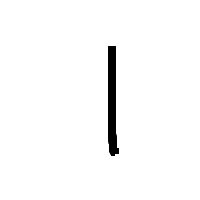

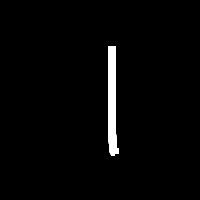

In [62]:
from PIL import Image, ImageOps
img = img.convert('L')	# grayscale
display(img)
img = ImageOps.invert(img)	# negate
display(img)
img = img.crop(box=img.getbbox())	# crop
display(img)
wd, ht = img.size
# アスペクト比を変えずに20x20の矩形に収める
if wd < ht:
  wd = wd * 20 // ht
  ht = 20
else:
  ht = ht * 20 // wd
  wd = 20
#img = img.resize((wd, ht), Image.Resampling.LANCZOS)
img = img.resize((wd, ht))
display(img)
cx, cy = centerOfMass(img)	# 重心

# 重心を中心にして28x28の矩形の中に配置
bgImg = Image.new(img.mode, (28, 28), color=0)
ox = -cx + 28 // 2
oy = -cy + 28 // 2
bgImg.paste(img, (ox, oy))
img = bgImg
display(img)

## ここまでの関数 drawdigit() にまとめておく
関数の返り値 (return) は，28×28 の画像をさらに，NumPy の ndarray にし，1×784 の1次元配列に変換（Flatten）したものを返す．  
これで，そのまま，clf.predict に渡して認識（予測）できる．

In [63]:
def drawdigit():
  canvas_html = """
  <canvas width=%d height=%d></canvas>
  <button>数字保存！</button>
  <script>
  var canvas = document.querySelector('canvas')
  var ctx = canvas.getContext('2d')
  canvas.style.border = "2px solid"
  ctx.lineWidth = %d
  var button = document.querySelector('button')
  var mouse = {x: 0, y: 0}
  canvas.addEventListener('mousemove', function(e) {
    mouse.x = e.pageX - this.offsetLeft
    mouse.y = e.pageY - this.offsetTop
  })
  canvas.onmousedown = ()=>{
    ctx.beginPath()
    ctx.moveTo(mouse.x, mouse.y)
    canvas.addEventListener('mousemove', onPaint)
  }
  canvas.onmouseup = ()=>{
    canvas.removeEventListener('mousemove', onPaint)
  }
  var onPaint = ()=>{
    ctx.lineTo(mouse.x, mouse.y)
    ctx.stroke()
  }
  var data = new Promise(resolve=>{
    button.onclick = ()=>{
      resolve(canvas.toDataURL('image/png'))
    }
  })
  </script>
  """

  display(HTML(canvas_html % (200, 200, 8)))
  data = eval_js("data")
  binary = b64decode(data.split(',')[1])
  img = Image.open(BytesIO(binary))

  background = Image.new("RGB", img.size, (255, 255, 255))
  background.paste(img, img)
  img = background

  img = img.convert('L')	# grayscale
  img = ImageOps.invert(img)	# negate
  img = img.crop(box=img.getbbox())	# crop
  wd, ht = img.size
  # アスペクト比を変えずに20x20の矩形に収める
  if wd < ht:
    wd = wd * 20 // ht
    ht = 20
  else:
    ht = ht * 20 // wd
    wd = 20
  #img = img.resize((wd, ht), Image.Resampling.LANCZOS)
  img = img.resize((wd, ht))
  cx, cy = centerOfMass(img)	# 重心

  # 重心を中心にして28x28の矩形の中に配置
  bgImg = Image.new(img.mode, (28, 28), color=0)
  ox = -cx + 28 // 2
  oy = -cy + 28 // 2
  bgImg.paste(img, (ox, oy))
  img = bgImg
  display(img)
  return np.asarray(img).astype(np.float32).reshape(1, 784)


## drawdigit() を実行し数字を手書きする．
```python
suuji = drawdigit()
```

In [64]:
suuji = drawdigit()

## clf_***.predict に suuji を入れて認識させる
```python
print( clf_***.predict(suuji) )
```
または
```python
print( clf_***.predict(suuji)[0] )
```
[0] は配列の1つ目の値だけを取る操作

In [65]:
print( clf_lf.predict(suuji)[0] )

6


### 確率も見てみる

<BarContainer object of 10 artists>

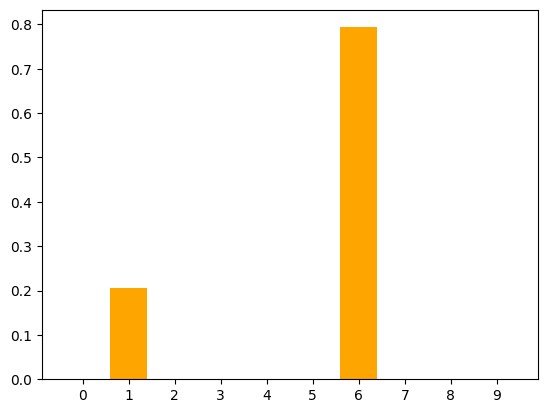

In [69]:
#各クラスの確率をグラフで見てみる
classes = list(map(str, range(10)))
#classes = ['0','1','2','3','4','5','6','7','8','9']
probabilities =clf_lf.predict_proba(suuji).reshape(10,)
plt.bar(classes, probabilities, color=['orange'])

# 宿題1. 課外時間に下記を実行して報告してください．

### a. モデルは，は線形ロジスティック回帰モデル
### b. データは訓練用データ 60000 個，テスト用データ 10000個全て使う
### c. 評価は，適合率，再現率，F1スコア，正答率，混同行列を示す

# 第3回：訓練データ60000 でモデルを作った場合の精度を下記の Google Drive に書いて下さい．グループの中で，最も良いものを書いてください．

https://docs.google.com/spreadsheets/d/1TzltXaL8OJ13B53p_A-wD9xgUu-v582p9CJXheGbhOc/edit?gid=0#gid=0

# 第3回

## 実習1，予測確率を見てみる（ロジスティック（シグモイド）→ソフトマックス値）

## 実習2，重みマップ（係数）を見てみる

## 実習3，手書きデータを認識してみる

## 宿題2 →第3回実習続き. Scikit-Learnの他のモデル，ハイパーパラメータを試し，全データを作った訓練で，どこまで精度高められるか試す．ただし，実習中はデータ数1000でやってみる．

例えば，
### a1. 線形ロジスティック回帰の場合は，正則化 elastic-net を使って，L1_ratio や, alpha を変更

### a2. SVM の場合は，カーネルの種類，C や gamma 等のパラメータ値

### a3. 多層パーセプトロンの場合は隠れ層の数と，ニューロン数の変更


等．
### b. 下記サイトを参考に他のアルゴリズム（授業で用いなかったものも可）を試し精度向上を検討しなさい．

https://scikit-learn.org/stable/supervised_learning.html  

# 第3回(6/16)の宿題： 手書きの数字を20回程度様々な数字を書いてみて，分類精度を確かめて，テストデータの精度と比較しなさい（次回，入力フォームを用意します）．


